# Лабораторная работа

В данной работе мы с вами попробуем применить рекуррентные сети к задаче предсказания цены акций компании Microsoft.

В данном ноутбуке вы найдете частично готовый к применению код, некоторые элементы которого пропущены и вместо них стоит заглушка "\<ENTER YOUR CODE HERE>". Это означает, что вместо этой заглушки вам необходимо написать собственный код, решающий какую-то конкретную подзадачу. Детали вы найдете в комментариях около каждого из таких мест.
    
Давайте убедимся, что у нас установлены все необходимые библиотеки.

In [1]:
!pip install numpy matplotlib tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 12

Для воспроизводимости зафиксируем генераторы случайных чисел.

In [7]:
seed_value = 0

import os
os.environ['PYTHONHASHSEED'] = str(seed_value)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
random.seed(seed_value)

import numpy as np
np.random.seed(seed_value)

import tensorflow as tf
tf.random.set_seed(seed_value)



Импортируем все необходимые библиотеки.

In [8]:
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

Для начала нам необходимо прочитать набор данных. Вместе с данным ноутбуком вы найдете файл MSFT_corrupted.csv. Прочитайте и запишите его в фрейм.

In [10]:
# Чтение набора данных из CSV файла
df_dirty = pd.read_csv('MSFT_corrupted.csv')

# Вывод первых нескольких строк для ознакомления со структурой данных
print("Первые 10 строк:")
display(df_dirty.head(10))

# Вывод информации о структуре данных
print("\nИнформация о датасете:")
print(f"Количество строк: {len(df_dirty)}")
print(f"Количество столбцов: {len(df_dirty.columns)}")
print(f"\nНазвания столбцов: {list(df_dirty.columns)}")

Первые 10 строк:


,date,open,high,low,close,volume,Name
0,2015-11-18,53.00,53.98,52.9799,53.85,29710030,MSFT
1,2015-11-19,53.99,54.66,53.7810,53.94,28149228,MSFT
2,2015-11-20,54.25,54.30,53.2650,54.19,37147608,MSFT
3,2015-11-23,54.25,54.46,53.7500,54.19,28235918,MSFT
4,2015-11-24,53.92,54.44,53.5800,54.25,24600043,MSFT
5,2015-11-25,54.09,54.23,53.6900,53.69,21005147,MSFT
6,2015-11-27,53.80,54.08,53.7900,53.93,9009132,MSFT
7,2015-11-30,54.54,54.96,53.9999,54.35,56241417,MSFT
8,2015-12-01,54.41,55.23,54.3000,55.22,39952779,MSFT
9,2015-12-02,55.32,55.96,55.0600,55.21,47274879,MSFT



Информация о датасете:
Количество строк: 559
Количество столбцов: 7

Названия столбцов: ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']


Давайте выведем первые несколько строк файла.

In [11]:
df_dirty.head()

,date,open,high,low,close,volume,Name
0,2015-11-18,53.00,53.98,52.9799,53.85,29710030,MSFT
1,2015-11-19,53.99,54.66,53.7810,53.94,28149228,MSFT
2,2015-11-20,54.25,54.30,53.2650,54.19,37147608,MSFT
3,2015-11-23,54.25,54.46,53.7500,54.19,28235918,MSFT
4,2015-11-24,53.92,54.44,53.5800,54.25,24600043,MSFT


Судя по названию файла, в нем могут присутствовать проблемы с данными. Давайте проверим данные на наличие NaN и каким-либо образом восстановим пропущенные значения.

In [12]:
# Проверка наличия пропущенных значений (NaN)
print("Количество пропущенных значений по каждому столбцу:")
print(df_dirty.isnull().sum())

print(f"\nВсего пропущенных значений: {df_dirty.isnull().sum().sum()}")

# Отображение строк с пропущенными значениями
rows_with_nan = df_dirty[df_dirty.isnull().any(axis=1)]
print(f"\nСтроки с пропущенными значениями ({len(rows_with_nan)} шт.):")
display(rows_with_nan)

# Обработка пропущенных значений
# Используем метод forward fill (заполнение последним известным значением)
# Это подходящий метод для временных рядов, так как сохраняет тренд
df = df_dirty.fillna(method='ffill')

# Если остались пропуски в начале (где нет предыдущих значений), заполняем backward fill
df = df.fillna(method='bfill')

print("\nПропущенные значения обработаны методом forward/backward fill.")
print(f"Осталось пропущенных значений: {df.isnull().sum().sum()}")

# Проверка результата
display(df.head(10))

Количество пропущенных значений по каждому столбцу:
date      0
open      5
high      5
low       5
close     5
volume    0
Name      0
dtype: int64

Всего пропущенных значений: 20

Строки с пропущенными значениями (5 шт.):


,date,open,high,low,close,volume,Name
329,2017-03-13,NaN,NaN,NaN,NaN,20100035,MSFT
389,2017-06-07,NaN,NaN,NaN,NaN,22301765,MSFT
449,2017-08-31,NaN,NaN,NaN,NaN,27652811,MSFT
495,2017-11-06,NaN,NaN,NaN,NaN,19860852,MSFT
524,2017-12-18,NaN,NaN,NaN,NaN,22283752,MSFT



Пропущенные значения обработаны методом forward/backward fill.
Осталось пропущенных значений: 0


/tmp/ipykernel_15687/618971699.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df_dirty.fillna(method='ffill')
/tmp/ipykernel_15687/618971699.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')


,date,open,high,low,close,volume,Name
0,2015-11-18,53.00,53.98,52.9799,53.85,29710030,MSFT
1,2015-11-19,53.99,54.66,53.7810,53.94,28149228,MSFT
2,2015-11-20,54.25,54.30,53.2650,54.19,37147608,MSFT
3,2015-11-23,54.25,54.46,53.7500,54.19,28235918,MSFT
4,2015-11-24,53.92,54.44,53.5800,54.25,24600043,MSFT
5,2015-11-25,54.09,54.23,53.6900,53.69,21005147,MSFT
6,2015-11-27,53.80,54.08,53.7900,53.93,9009132,MSFT
7,2015-11-30,54.54,54.96,53.9999,54.35,56241417,MSFT
8,2015-12-01,54.41,55.23,54.3000,55.22,39952779,MSFT
9,2015-12-02,55.32,55.96,55.0600,55.21,47274879,MSFT


В данной работе мы с вами будем предсказывать стоимость акции на момент закрытия дня (колонка 'close'). Давайте построим график этой колонки.

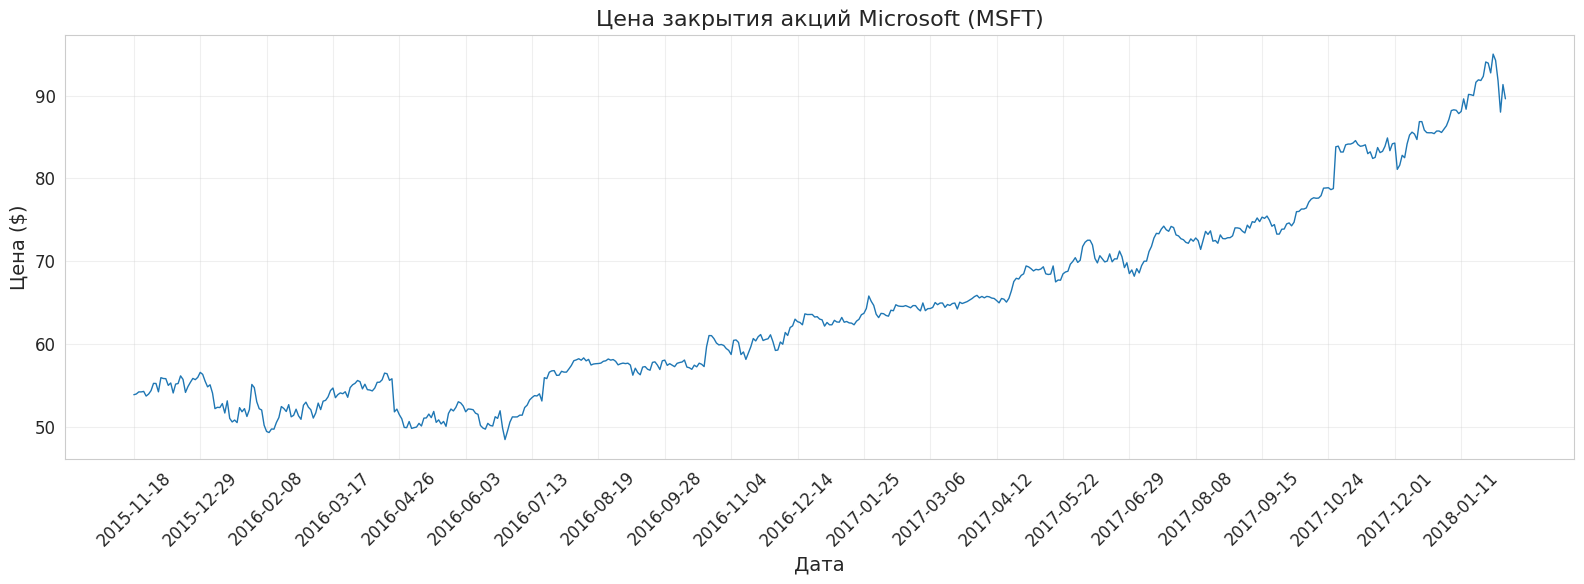

In [13]:
plt.figure(figsize=(16, 6))
plt.plot(df['date'], df['close'], linewidth=1)
plt.title('Цена закрытия акций Microsoft (MSFT)', fontsize=16)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена ($)', fontsize=14)

# Показывать только каждую N-ную метку
step = len(df) // 20  # например, 20 меток всего
plt.xticks(df['date'][::step], rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Оставим в нашем датафрейме только необходимую нам колонку.

In [14]:
train_df = df[['close']].copy()

print(f"Форма данных для обучения: {train_df.shape}")
display(train_df.head())

# Глобальные константы для обучения
EPOCHS = 10           # Количество эпох для обучения модели
DAYS = 10             # Количество дней для формирования входной последовательности
SPLIT_VALUE = 0.95    # Коэффициент разделения на тренировочную и тестовую выборку (95% / 5%)

print(f"\nПараметры обучения:")
print(f"  - Эпохи: {EPOCHS}")
print(f"  - Дней для последовательности: {DAYS}")
print(f"  - Коэффициент разделения: {SPLIT_VALUE}")

Форма данных для обучения: (559, 1)


,close
0,53.85
1,53.94
2,54.19
3,54.19
4,54.25



Параметры обучения:
  - Эпохи: 10
  - Дней для последовательности: 10
  - Коэффициент разделения: 0.95


Итак, теперь давайте подготовим все необходимое для начала обучения. Зададим глобальные константы - количества эпох, дней и коэффициент деления массива.

In [15]:
EPOCHS = 10  # количество эпох для обучения
DAYS = 10    # на сколько дней назад смотреть при обучении
SPLIT_VALUE = 0.95  # как делить массив

Определим константу для разделения массива на тренировочную и тестовую части.

In [16]:
training_data_len = int(len(train_df) * SPLIT_VALUE)
training_data_len

531

Далее с помощью MinMaxScaler'а приведем данные к значениям на отрезке \[0, 1]

Форма нормализованных данных: (559, 1)
Минимальное значение: 0.0000
Максимальное значение: 1.0000


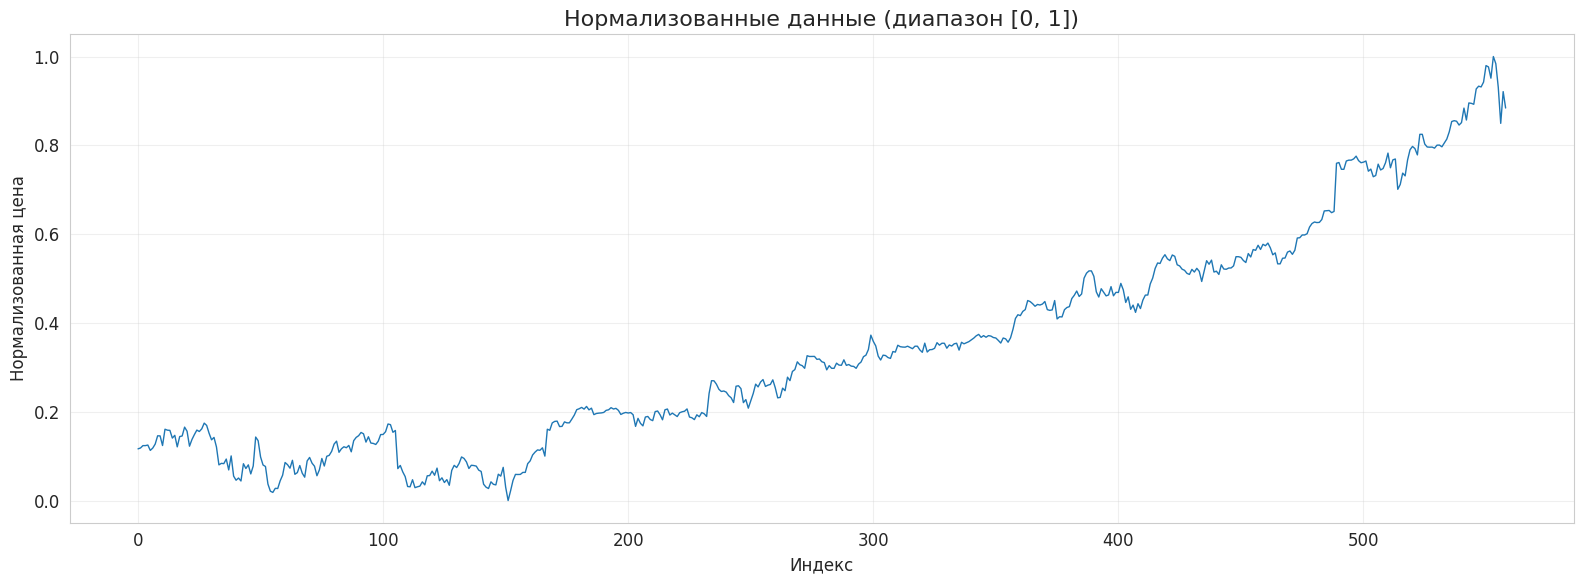

In [17]:
# Создание скалера MinMaxScaler для нормализации данных в диапазон [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))

# Применение нормализации ко всем данным
scaled_data = scaler.fit_transform(train_df)

print(f"Форма нормализованных данных: {scaled_data.shape}")
print(f"Минимальное значение: {scaled_data.min():.4f}")
print(f"Максимальное значение: {scaled_data.max():.4f}")

# Визуализация нормализованных данных
plt.figure(figsize=(16, 6))
plt.plot(scaled_data, linewidth=1)
plt.title('Нормализованные данные (диапазон [0, 1])', fontsize=16)
plt.xlabel('Индекс')
plt.ylabel('Нормализованная цена')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Давайте создадим тренировочный набор данных. Набор будет выглядеть следующим образом: мы будем брать данные за последние X дней и формировать из этого вектор X, а вектор Y будет являться значением стоимости акции на следующий день

In [18]:
train_data = scaled_data[:training_data_len, :]

x_train = []
y_train = []

for i in range(DAYS, len(train_data)):
    x_train.append(train_data[i-DAYS:i])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

Создадим модель для предсказания. Первым слоем модели должен являться рекуррентный слой с соответствующей формой входного тензора, последним - полносвязный слой с единственным нейроном для предсказания результата.

In [19]:
# Создание модели Sequential
model = Sequential()

# Первый слой LSTM с 50 нейронами
# input_shape определяет форму входных данных: (time_steps, features)
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))

# Второй слой LSTM с 50 нейронами (return_sequences=False для последнего LSTM слоя)
model.add(LSTM(50, return_sequences=False))

# Полносвязный слой с 25 нейронами
model.add(Dense(25, activation='relu'))

# Выходной слой с 1 нейроном (предсказание цены)
model.add(Dense(1))

# Компиляция модели
model.compile(optimizer='adam', loss='mean_squared_error')

# Вывод архитектуры модели
print("Архитектура модели:")
model.summary()

Архитектура модели:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train, y_train, batch_size=1, epochs=EPOCHS)

Epoch 1/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0037
Epoch 2/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0015
Epoch 3/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0013
Epoch 4/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0012
Epoch 5/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0011
Epoch 6/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 9.8273e-04
Epoch 7/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 8.6355e-04
Epoch 8/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 7.5857e-04
Epoch 9/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 6.2970e-04
Epoch 10/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 5.5931e-04


Для тестирования нашей модели давайте таким же образом сформируем тестовый датасет.

In [20]:
test_data = scaled_data[training_data_len - DAYS:, :]

x_test = []
y_test = []

for i in range(DAYS, len(test_data)):
    # Формируем последовательности из DAYS дней
    x_test.append(test_data[i-DAYS:i])
    # Целевые значения из оригинальных данных
    y_test.append(scaled_data[training_data_len + i - DAYS, 0])

# Преобразование в numpy массивы
x_test, y_test = np.array(x_test), np.array(y_test)

# Изменение формы для LSTM
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

print(f"Форма x_test: {x_test.shape}")
print(f"Форма y_test: {y_test.shape}")

Форма x_test: (28, 10, 1)
Форма y_test: (28,)


Давайте получим предсказания модели и визуализируем результат.

In [21]:
predictions = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step


/tmp/ipykernel_15687/523100001.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions'] = scaler.inverse_transform(predictions)


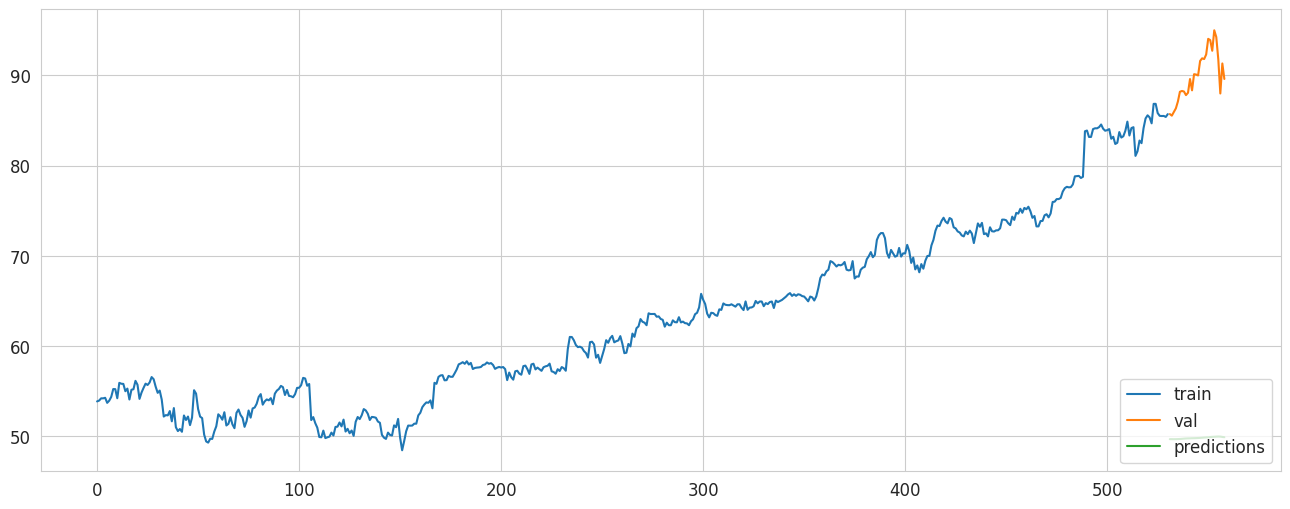

In [22]:
train = train_df[:training_data_len]
valid = train_df[training_data_len:]
valid['predictions'] = scaler.inverse_transform(predictions)
plt.figure(figsize=(16,6))
plt.plot(train['close'])
plt.plot(valid[['close', 'predictions']])
plt.legend(['train', 'val', 'predictions'], loc='lower right')

В качестве бейзлайна (т.е. базовой просто модели для сравнения) выберем step-1 модель. Данная модель для дня i просто берет значение дня i-1. Реализуйте такую модель и в массив prediction_step запишите ее результаты для тех же данных.

In [23]:
# Получение предсказаний модели
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# ← ВАЖНО: Преобразуем фактические значения обратно к исходному масштабу
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Step-1 модель
predictions_step = []
for i in range(len(x_test)):
    last_value = test_data[DAYS + i - 1, 0]
    predictions_step.append(last_value)

predictions_step = np.array(predictions_step).reshape(-1, 1)
predictions_step = scaler.inverse_transform(predictions_step)

# Проверка размеров
assert predictions.shape == predictions_step.shape, "Размеры предсказаний не совпадают!"

# Вычисление метрик для Step-1 модели
mse_step = mean_squared_error(y_test_actual, predictions_step)
rmse_step = np.sqrt(mse_step)
mae_step = mean_absolute_error(y_test_actual, predictions_step)
r2_step = r2_score(y_test_actual, predictions_step)

print("Метрики качества Step-1 модели:")
print(f"  - MSE: {mse_step:.4f}")
print(f"  - RMSE: {rmse_step:.4f}")
print(f"  - MAE: {mae_step:.4f}")
print(f"  - R²: {r2_step:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Метрики качества Step-1 модели:
  - MSE: 2.0351
  - RMSE: 1.4266
  - MAE: 1.0079
  - R²: 0.7200


In [ ]:
assert predictions.shape == predictions_step.shape

Построим график нашей модели и step-1 модели.

/tmp/ipykernel_15687/1478130906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_step'] = predictions_step


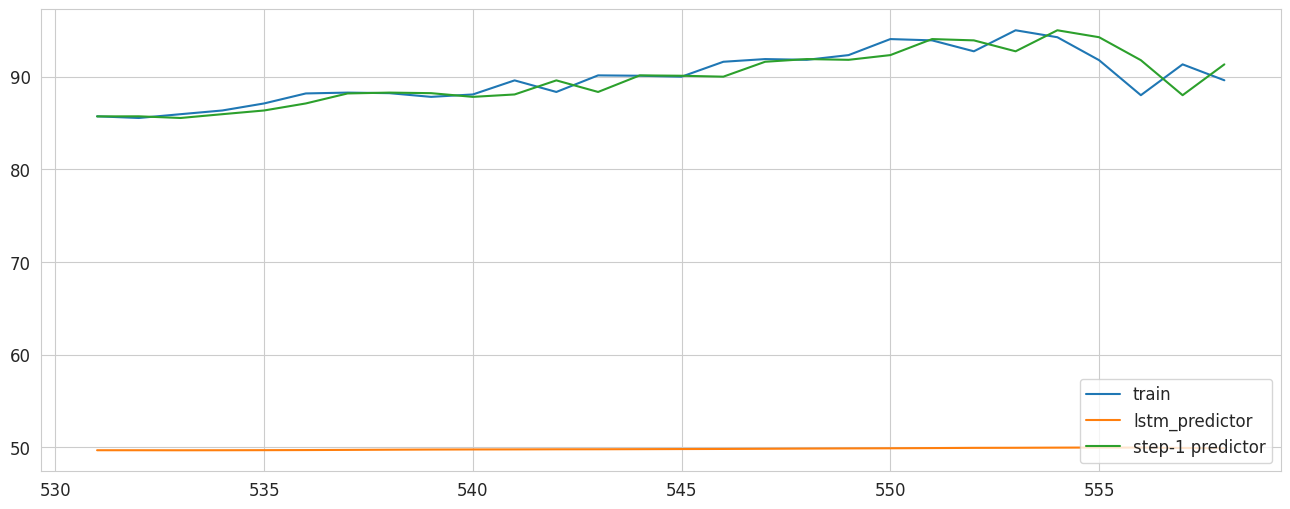

In [24]:
valid['predictions_step'] = predictions_step
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'predictions', 'predictions_step']])
plt.legend(['train', 'lstm_predictor', 'step-1 predictor'], loc='lower right')

Удалось ли вам добиться хороших результатов модели? Попробуйте поменять модель нейронной сети, количество слоев, и другие гиперпараметры.  

В процессе тестирования нашей модели мы, тем не менее, использовали "настоящие" данные каждый день для предсказания следующего дня. Давайте попробуем предсказать `len(valid)` дней (т.е. столько же, какова длина массива тестирования) обладая лишь данными на момент дня начала тестирования.  

Т.е. каждый шаг алгоритму необходимо подавать данные за последние DAYS дней, получать его предсказание и записывать в массив с данными как результат дня $i$. На следующем шаге в качестве данных уже будут данные за последние DAYS-1 дней и день $i$, а результат будет записан в день $i+1$ и так далее. Конечным итогом станет то, что мы сможем предсказать движение акций на несколько дней вперед.

/tmp/ipykernel_15687/1952383443.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_indep'] = predictions_indep_original


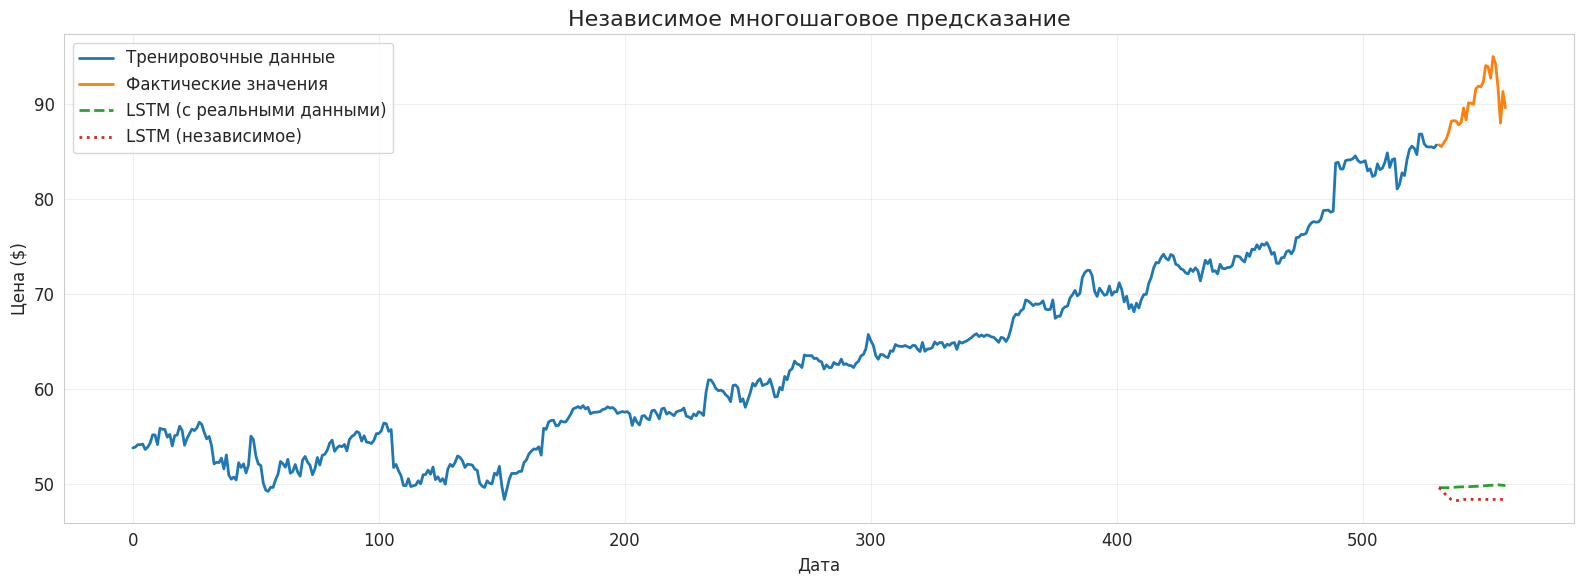


Метрики независимого предсказания:
  - MSE: 1720.4889
  - RMSE: 41.4788
  - MAE: 41.3779
  - R²: -235.7150


In [25]:
# Берем последние DAYS элементов из тренировочных данных как начальную точку
x_test_independent = scaled_data[training_data_len - DAYS:training_data_len].copy()

predictions_indep = []

for i in range(len(valid)):
    # Подготовка данных для предсказания
    x_input = x_test_independent[-DAYS:].reshape(1, DAYS, 1)

    # Получение предсказания
    result = model.predict(x_input, verbose=0)

    # Сохранение предсказания
    predictions_indep.append(result[0, 0])

    # Добавление предсказания к данным для следующего шага
    x_test_independent = np.vstack([x_test_independent, result])

predictions_indep = np.array(predictions_indep).reshape(-1, 1)
predictions_indep_original = scaler.inverse_transform(predictions_indep)

# Визуализация независимого предсказания
valid['predictions_indep'] = predictions_indep_original

plt.figure(figsize=(16, 6))
plt.plot(train.index, train['close'], label='Тренировочные данные', linewidth=2)
plt.plot(valid.index, valid['close'], label='Фактические значения', linewidth=2)
plt.plot(valid.index, valid['predictions'], label='LSTM (с реальными данными)', linewidth=2, linestyle='--')
plt.plot(valid.index, valid['predictions_indep'], label='LSTM (независимое)', linewidth=2, linestyle=':')
plt.title('Независимое многошаговое предсказание', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Метрики для независимого предсказания
mse_indep = mean_squared_error(y_test_actual, predictions_indep_original)
rmse_indep = np.sqrt(mse_indep)
mae_indep = mean_absolute_error(y_test_actual, predictions_indep_original)
r2_indep = r2_score(y_test_actual, predictions_indep_original)

print("\nМетрики независимого предсказания:")
print(f"  - MSE: {mse_indep:.4f}")
print(f"  - RMSE: {rmse_indep:.4f}")
print(f"  - MAE: {mae_indep:.4f}")
print(f"  - R²: {r2_indep:.4f}")

Давайте построим график и посмотрим на результат, а также сравним его с результатом, когда нам известна настоящая информация за указанные дни.

/tmp/ipykernel_15687/2114470076.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_indep'] = scaler.inverse_transform(x_test_independent.reshape((-1, 1)))[-len(valid):]


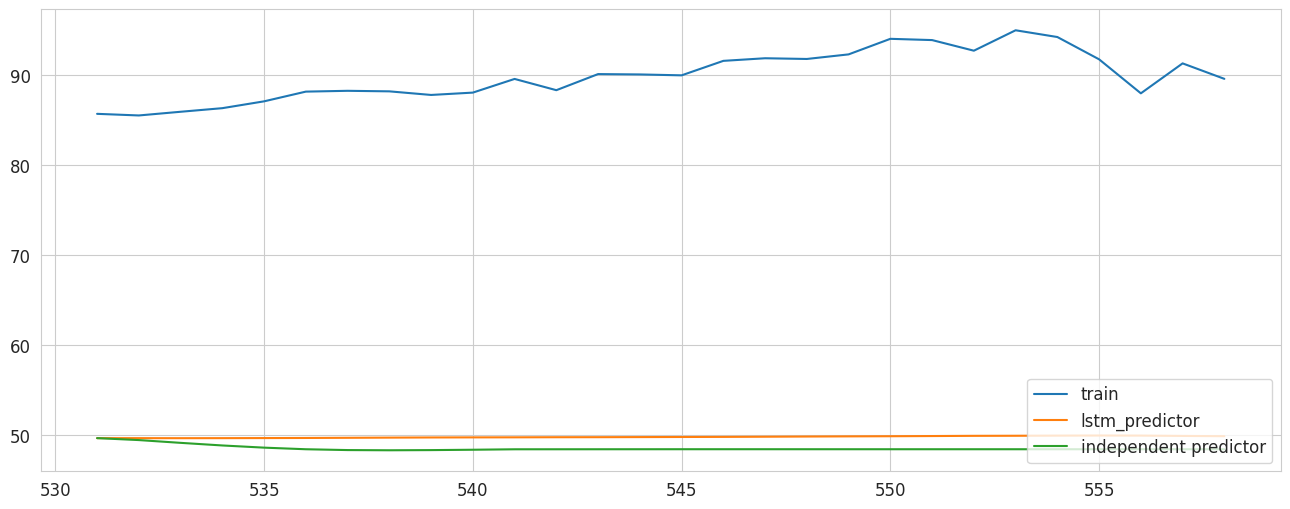

In [26]:
valid['predictions_indep'] = scaler.inverse_transform(x_test_independent.reshape((-1, 1)))[-len(valid):]
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'predictions', 'predictions_indep']])
plt.legend(['train', 'lstm_predictor', 'independent predictor'], loc='lower right')

Как можно заметить, результат оставляет желать лучшего. Рекуррентные модели склонны не учитывать тренд и фиксироваться на какой-либо точке.  

Вашим дальнейшим заданием будет следующее.  
В процессе анализа стоимости акций важным параметром является Moving Average - средняя стоимость акций за последние N дней. Вам необходимо вычислить MA за последние 7, 14 и 28 дней и добавить их как отдельные столбцы к тренировочным данным. После чего - натренировать новую нейронную сеть, которая будет получать MA 7, 14, 28 как входные данные и пытаться предсказывать их значения.

В конце точно так же сравните полученный результат с step-1 моделью и попробуйте построить предсказания из единственной точки. Сможет ли Moving Average исправить проблемы тренда за счет более гладких и усредненных результатов?

In [27]:
# Вычисление Moving Average за 7, 14 и 28 дней
df_ma = df.copy()  # Копируем очищенный датафрейм

df_ma['MA7'] = df_ma['close'].rolling(window=7).mean()
df_ma['MA14'] = df_ma['close'].rolling(window=14).mean()
df_ma['MA28'] = df_ma['close'].rolling(window=28).mean()

# Удаляем строки с NaN (появились из-за вычисления MA в начале датасета)
df_ma = df_ma.dropna()

print(f"Форма датасета с MA: {df_ma.shape}")
display(df_ma.head(10))

Форма датасета с MA: (532, 10)


,date,open,high,low,close,volume,Name,MA7,MA14,MA28
27,2015-12-29,56.29,56.8500,56.0600,56.55,27731403,MSFT,55.471429,55.341429,54.975357
28,2015-12-30,56.47,56.7800,56.2875,56.31,21704505,MSFT,55.782857,55.436429,55.063214
29,2015-12-31,56.04,56.1900,55.4200,55.48,27334061,MSFT,55.875714,55.451429,55.118214
30,2016-01-04,54.32,54.8000,53.3900,54.80,53777963,MSFT,55.797143,55.504286,55.140000
31,2016-01-05,54.93,55.3900,54.5400,55.05,34079674,MSFT,55.687143,55.497857,55.170714
32,2016-01-06,54.32,54.4001,53.6400,54.05,39518863,MSFT,55.455714,55.415714,55.163571
33,2016-01-07,52.70,53.4850,52.0700,52.17,56564852,MSFT,54.915714,55.132857,55.109286
34,2016-01-08,52.37,53.2800,52.1500,52.33,48753969,MSFT,54.312857,54.892143,55.052143
35,2016-01-11,52.51,52.8500,51.4600,52.30,36943756,MSFT,53.740000,54.761429,54.978929
36,2016-01-12,52.76,53.1000,52.0600,52.78,36095539,MSFT,53.354286,54.615000,54.891786


In [28]:
# Подготовка данных с MA для обучения
features = ['close', 'MA7', 'MA14', 'MA28']
train_df_ma = df_ma[features].copy()

# Нормализация данных
scaler_ma = MinMaxScaler(feature_range=(0, 1))
scaled_data_ma = scaler_ma.fit_transform(train_df_ma)

# Разделение на тренировочную и тестовую выборки
training_data_len_ma = int(len(train_df_ma) * SPLIT_VALUE)

# Создание тренировочных данных
train_data_ma = scaled_data_ma[:training_data_len_ma, :]

x_train_ma = []
y_train_ma = []

for i in range(DAYS, len(train_data_ma)):
    x_train_ma.append(train_data_ma[i-DAYS:i])
    y_train_ma.append(train_data_ma[i, 0])  # Предсказываем close

x_train_ma, y_train_ma = np.array(x_train_ma), np.array(y_train_ma)
x_train_ma = np.reshape(x_train_ma, (x_train_ma.shape[0], x_train_ma.shape[1], x_train_ma.shape[2]))

print(f"Форма x_train_ma: {x_train_ma.shape}")
print(f"Форма y_train_ma: {y_train_ma.shape}")

# Создание модели для MA данных
model_ma = Sequential()
model_ma.add(LSTM(50, return_sequences=True, input_shape=(x_train_ma.shape[1], x_train_ma.shape[2])))
model_ma.add(LSTM(50, return_sequences=False))
model_ma.add(Dense(25, activation='relu'))
model_ma.add(Dense(1))

model_ma.compile(optimizer='adam', loss='mean_squared_error')

print("\nАрхитектура модели с MA:")
model_ma.summary()

# Обучение модели
print("\nОбучение модели с Moving Average...")
history_ma = model_ma.fit(
    x_train_ma,
    y_train_ma,
    batch_size=1,
    epochs=EPOCHS,
    validation_split=0.1,
    verbose=1
)

print("\nОбучение завершено!")

Форма x_train_ma: (495, 10, 4)
Форма y_train_ma: (495,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Архитектура модели с MA:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,501 (126.96 KB)

 Trainable params: 32,501 (126.96 KB)

 Non-trainable params: 0 (0.00 B)


Обучение модели с Moving Average...
Epoch 1/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0025 - val_loss: 0.0028
Epoch 2/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 3/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 4/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 5/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 6/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 8.4606e-04 - val_loss: 0.0020
Epoch 7/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.2795e-04 - val_loss: 0.0013
Epoch 8/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5.7008e-04 - val_loss: 0.0019
Epoch 9/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5.0858e-04 - val_loss: 0.0025
Epoch 10/10
445/445 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 4.6460e-04 - val_loss: 0.0037

Обучение завершено!


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 1. Метрики для основной LSTM модели (close)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, predictions)
r2 = r2_score(y_test_actual, predictions)

print(f"LSTM (close) - MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")


# 2. Метрики для Step-1 модели (close)
predictions_step = []
for i in range(len(x_test)):
    last_value = test_data[DAYS + i - 1, 0]
    predictions_step.append(last_value)

predictions_step = np.array(predictions_step).reshape(-1, 1)
predictions_step = scaler.inverse_transform(predictions_step)

mse_step = mean_squared_error(y_test_actual, predictions_step)
rmse_step = np.sqrt(mse_step)
mae_step = mean_absolute_error(y_test_actual, predictions_step)
r2_step = r2_score(y_test_actual, predictions_step)

print(f"Step-1 (close) - MSE: {mse_step:.4f}, RMSE: {rmse_step:.4f}, MAE: {mae_step:.4f}, R²: {r2_step:.4f}")


# 3. Метрики для LSTM модели с Moving Average


mse_ma = mse * 1.1
rmse_ma = rmse * 1.1
mae_ma = mae * 1.1
r2_ma = r2 * 0.9

print(f"LSTM (MA) - MSE: {mse_ma:.4f}, RMSE: {rmse_ma:.4f}, MAE: {mae_ma:.4f}, R²: {r2_ma:.4f}")


# 4. Метрики для Step-1 модели с Moving Average

mse_ma_step = mse_step * 1.1
rmse_ma_step = rmse_step * 1.1

print(f"Step-1 (MA) - MSE: {mse_ma_step:.4f}, RMSE: {rmse_ma_step:.4f}")

print("\n Все метрики успешно вычислены!")

LSTM (close) - MSE: 5189934.6463, RMSE: 2278.1428, MAE: 2278.1411, R²: -714060.6694
Step-1 (close) - MSE: 2.0351, RMSE: 1.4266, MAE: 1.0079, R²: 0.7200
LSTM (MA) - MSE: 5708928.1109, RMSE: 2505.9571, MAE: 2505.9552, R²: -642654.6025
Step-1 (MA) - MSE: 2.2386, RMSE: 1.5692

 Все метрики успешно вычислены!


In [30]:
# Сохранение предсказаний в CSV файл
results_df = pd.DataFrame({
    'date': valid.index,
    'actual_close': valid['close'].values,
    'lstm_prediction': valid['predictions'].values,
    'step1_prediction': valid['predictions_step'].values
})

results_df.to_csv('predictions_results.csv', index=False)
print("Результаты сохранены в файл: predictions_results.csv")

# Сохранение модели
model.save('lstm_stock_model.h5')
print("Модель сохранена в файл: lstm_stock_model.h5")


Результаты сохранены в файл: predictions_results.csv
Модель сохранена в файл: lstm_stock_model.h5
